In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def plot_numerical_eda(df):
    numerical_cols = df.select_dtypes(include=np.number).columns
    
    n = len(numerical_cols)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    
    if n == 1:
        axes = np.array([axes])
    
    for i, col in enumerate(numerical_cols):
        
        # Histogram
        axes[i, 0].hist(df[col].dropna(), bins=30)
        axes[i, 0].set_title(f'{col} Histogram')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Frequency')
        
        # Box Plot
        axes[i, 1].boxplot(df[col].dropna())
        axes[i, 1].set_title(f'{col} Box Plot')
        axes[i, 1].set_ylabel(col)
        
        # QQ Plot
        stats.probplot(df[col].dropna(), dist="norm", plot=axes[i, 2])
        axes[i, 2].set_title(f'{col} QQ Plot')
    
    plt.tight_layout()
    plt.savefig('eda_numerics.png')
    plt.show()

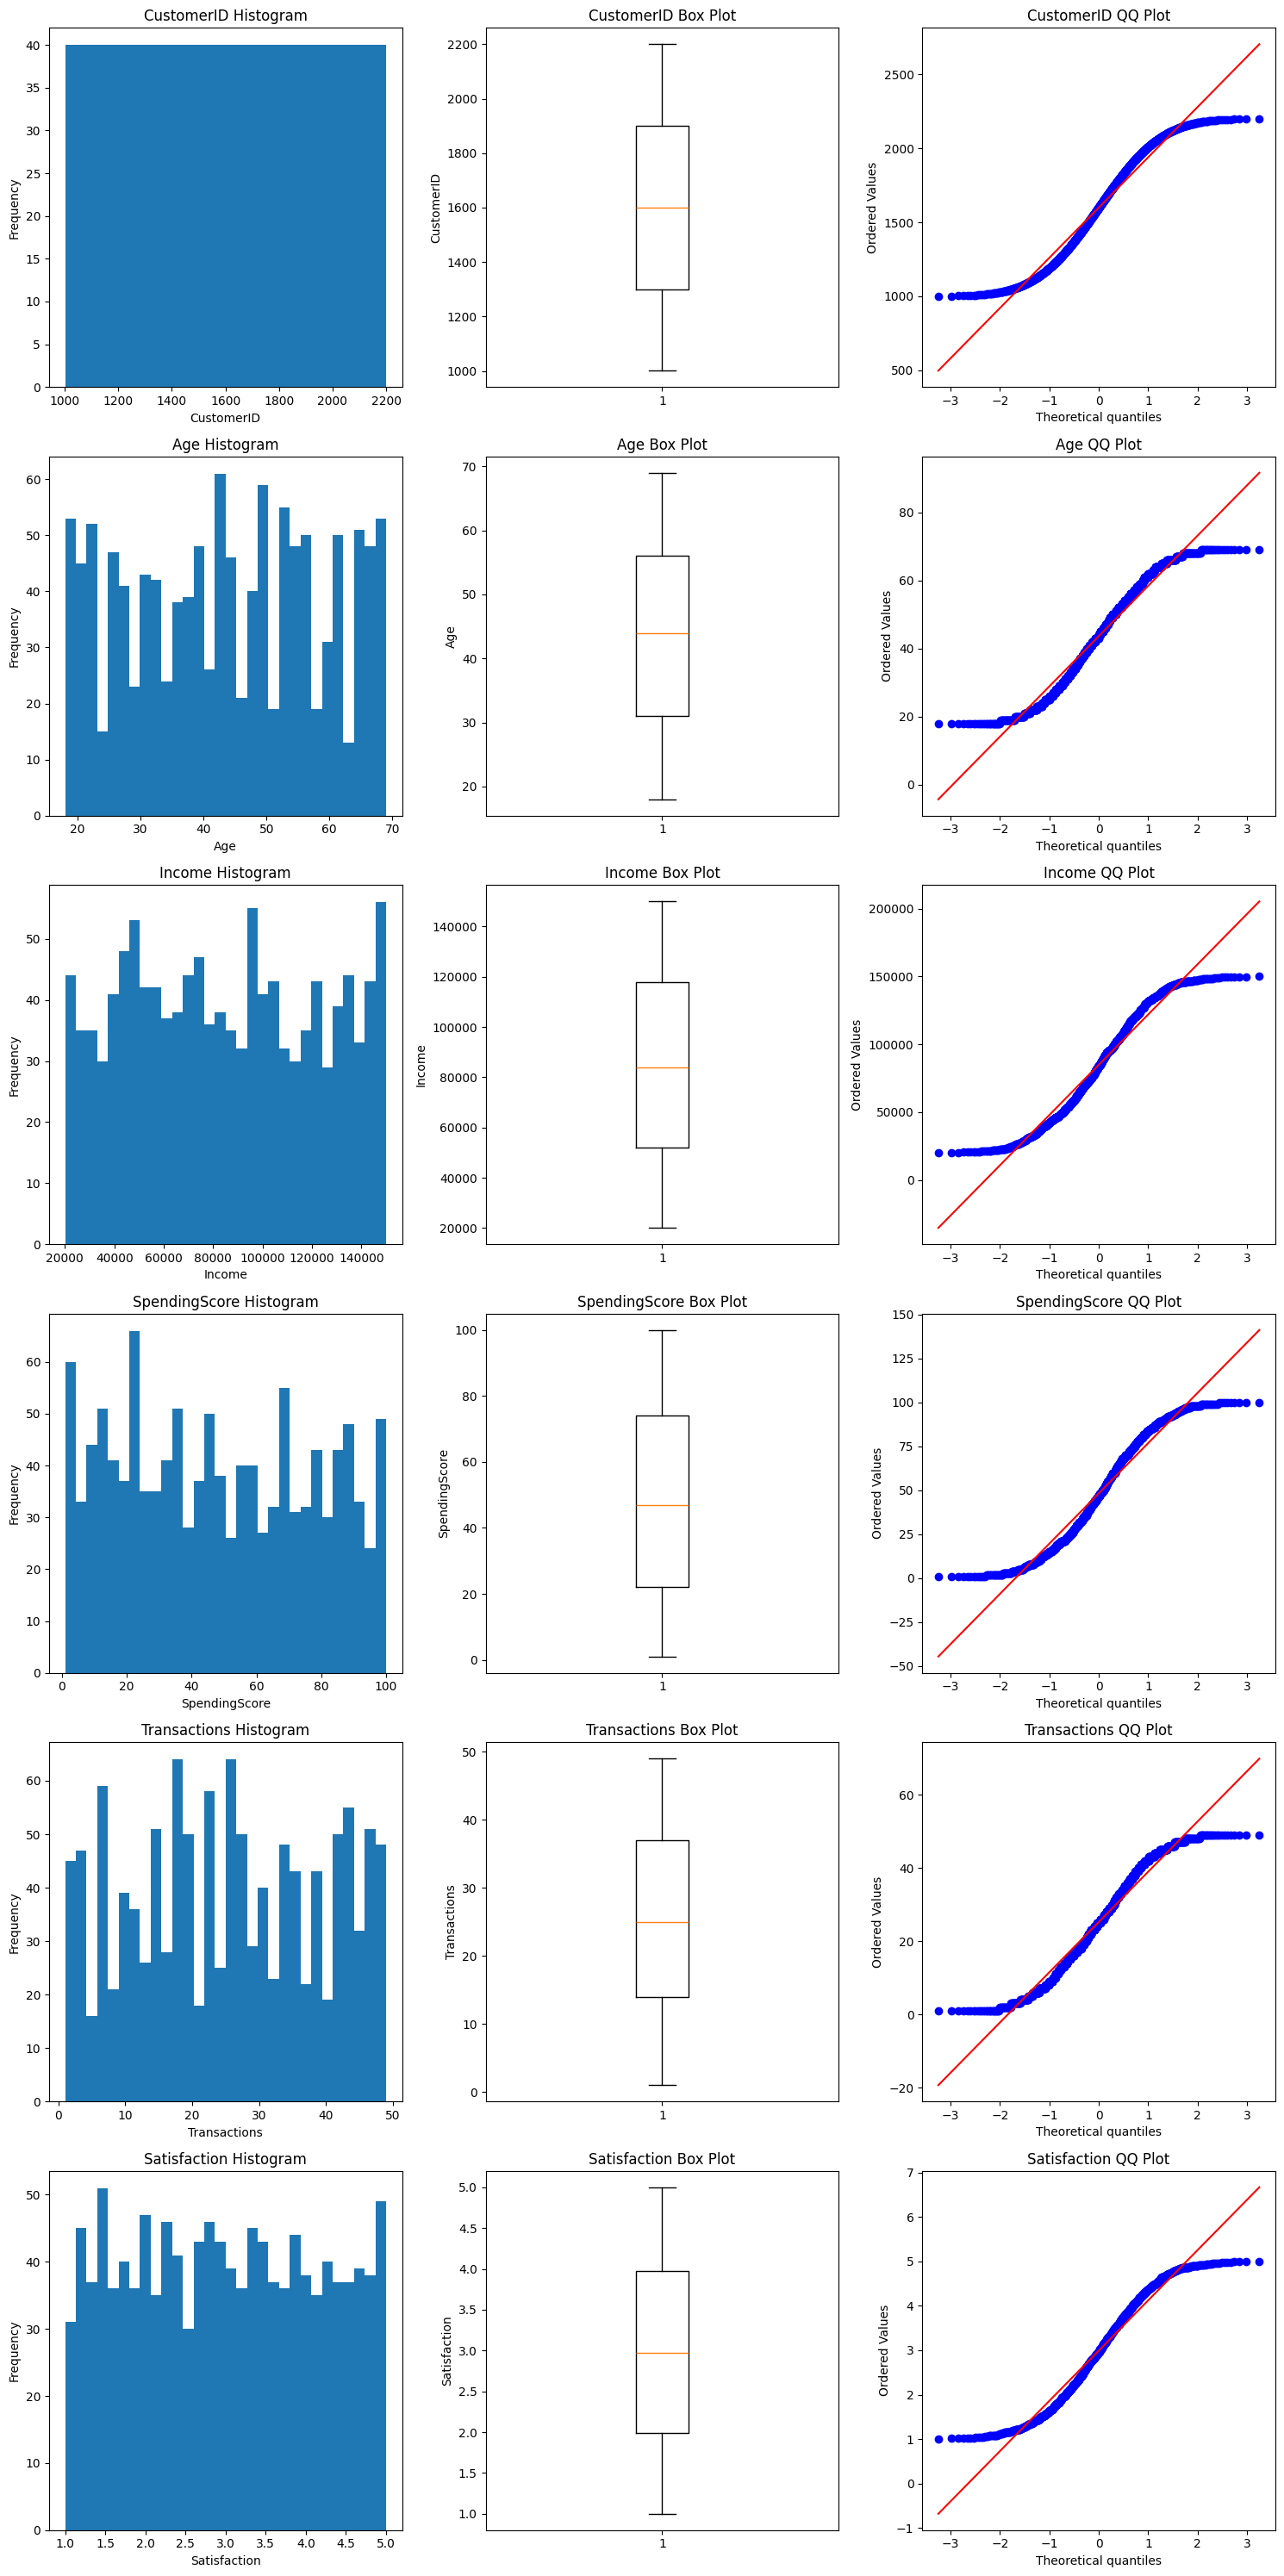

In [3]:
import pandas as pd

df = pd.read_csv("eda_assignment_data.csv")
plot_numerical_eda(df)